<a href="https://colab.research.google.com/github/javmencia/RelativeBelief/blob/Round2/LinReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import arviz as az

import pymc as pm
import pytensor.tensor as pt

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.special import gammaln
from scipy import stats
import time
import math
from matplotlib import cm
from scipy.stats import multivariate_normal

import numpy as np
from scipy.stats import norm, invgamma, multivariate_normal
import matplotlib.pyplot as plt

def normal_logp_np(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma) ** 2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)
def normal_logp(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma) ** 2 - pm.math.log(sigma) - 0.5*pm.math.log(2*np.pi)

from scipy.ndimage import gaussian_filter1d
from scipy.special import gammaln, betaln

def beta_logp(a, b, x):
    return (a - 1) * pm.math.log(x) + (b - 1) * pm.math.log(1 - x) - (gammaln(a) + gammaln(b) - gammaln(a + b))

def beta_logp_np(a, b, x):
    return (a - 1) * np.log(x) + (b - 1) * np.log(1 - x) - (gammaln(a) + gammaln(b) - gammaln(a + b))

def bernoulli_logp_np(p, x):
    return x * np.log(p) + (1 - x) * np.log(1 - p)

def bernoulli_logp_pm(p, x):
    return x * pm.math.log(p) + (1 - x) * pm.math.log(1 - p)

In [2]:
n = 10  # Number of observations
p = 2  # Number of covariates

# Design matrix X
# X = np.random.normal(size=(n, p))
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters for generating data
# beta0 = np.array([1, 2])
print(X)
β_true = np.logspace(0, 1, 2,base=2)
σ_true = 1
print(β_true)
mu0 = np.dot(X, β_true)

# Generate response variable y
# y = np.dot(X, beta0) + np.random.normal(0, sigma0, n)
np.random.seed(135)
y = X@β_true + stats.norm(0,σ_true).rvs(n)
β_true,X,y # print("y", y)



[[0. 0.]
 [0. 1.]
 [0. 0.]
 [0. 1.]
 [0. 0.]
 [1. 1.]
 [1. 0.]
 [1. 1.]
 [1. 0.]
 [1. 1.]]
[1. 2.]


(array([1., 2.]),
 array([[0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [1., 1.],
        [1., 0.],
        [1., 1.],
        [1., 0.],
        [1., 1.]]),
 array([-1.26485598,  3.18428092,  0.35504683,  1.70205735, -0.53348411,
         3.43950814,  1.54291277,  3.0241124 ,  0.07233906,  2.68438127]))

# Bias Against

## With PyMC

In [3]:
import numpy as np
import pymc as pm
import arviz as az

# Define prior parameters
mu_prior_mean = 0
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2


# Ground truth parameters for generating data
beta0 = β_true
sigma0 = 1
mu0 = np.dot(X, beta0)

with pm.Model() as model:
    # Priors
    beta = pm.Normal('beta', mu=mu_prior_mean, sigma=mu_prior_sigma, shape=(p,))
    #sigma = pm.TruncatedNormal("sigma", mu=sigma_prior_mu, sigma=sigma_prior_sigma, lower=0)
    sigma= pm.InverseGamma("sigma", alpha=sigma_prior_alpha, beta=sigma_prior_beta)
    # Likelihood
    mu = pm.Deterministic("mu", X@beta)
    y_ = pm.MvNormal('y_', mu=mu, cov=(sigma**2) * np.eye(n), shape=n)


    likelihood_prior_pdl = pm.Deterministic(f'likelihood_prior_pdl', pm.logp(pm.MvNormal.dist(mu=mu, cov=(sigma0**2) * np.eye(n), shape=n), y_).sum())
    # Sampling
    idata = pm.sample(draws=5000, tune=1000)



Output()

Output()

ERROR:pymc.stats.convergence:There were 105 divergences after tuning. Increase `target_accept` or reparameterize.


marginal likelihoods (2, 5000, 1000)
(2, 5000, 1000)
(2, 5000)
(2, 5000)


<ipython-input-4-b13a40bdd9f2>:17: RuntimeWarning: divide by zero encountered in log
  print(np.log(np.exp(marginal_likelihoods).mean(axis=-1)).shape)
<ipython-input-4-b13a40bdd9f2>:18: RuntimeWarning: divide by zero encountered in log
  print(np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel().shape)


(10000,)
[-10.16486774 -15.58657869 -14.48409031 -22.77721004 -15.99692842
 -17.53764937 -15.24148109 -16.06920959 -11.26178399 -14.71522406]
[-14.31137248 -19.36194128 -16.79185852 -27.6323267  -21.38863409
 -21.94813852 -20.61231591 -17.66454916 -15.2310469  -15.68385684]


<ipython-input-4-b13a40bdd9f2>:20: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()


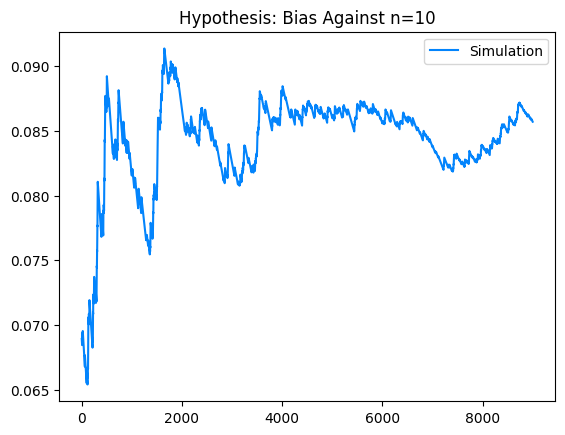

In [4]:
def normal_logp_np(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma) ** 2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)


# Calculate the bias against the prior hypothesis
burn = 1000

# Extract posterior samples for simulation
beta_samples = idata.posterior['beta'][:, :, 0].values.ravel()[:1000]
x_samples = idata.posterior['y_'].values  # Shape (chains, draws, n)

# Compute log likelihoods for all samples at once
marginal_likelihoods = normal_logp_np(x_samples[:, :, :, np.newaxis], beta_samples, 1).sum(axis=2)
print("marginal likelihoods", marginal_likelihoods.shape)
print(np.exp(marginal_likelihoods).shape)
print(np.exp(marginal_likelihoods).mean(axis=-1).shape)
print(np.log(np.exp(marginal_likelihoods).mean(axis=-1)).shape)
print(np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel().shape)
# Average the likelihoods over the samples
log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

# Compute biases
likelihood_prior_pd = idata.posterior['likelihood_prior_pdl'].values.ravel()

print(likelihood_prior_pd[-10:])
print(log_marginal_likelihoods[-10:])
bias_against_ml = (likelihood_prior_pd - log_marginal_likelihoods) <= 0

bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

plt.plot(bias_against_ml_mci[burn:], color="#0384fc", label='Simulation')
plt.title("Hypothesis: Bias Against n={}".format(n))
plt.legend()
plt.show()

Without PyMC

[ -2.43664395 -19.97377429  -7.77205153 ... -11.81272681  -8.46836535
 -16.85262351]
8.517193191416238
[-0.29618504  2.21031898  4.1216929  ...  7.14461453  4.60933778
  6.14599442]
[ -9.47910974 -23.33857505   0.70717276 ... -15.75467279 -10.63291511
  -4.96389115]
8.517193191416238
[ 5.32004894 -6.1698861  -3.19934508 ...  7.76108913  6.06037495
  1.90442255]
[ -5.51831116  -9.16914606  -4.62336889 ... -17.47739074 -10.04602932
 -15.54693095]
8.517193191416238
[2.49409601 5.05949748 1.60372618 ... 6.42384504 5.60052914 6.72025857]
[-12.59004666 -23.09887272 -12.39955177 ... -13.49284602 -14.60288508
  -7.54866325]
8.517193191416238
[6.80297313 2.73177065 6.84953504 ... 7.81070558 6.90386863 4.08596246]
[ -8.91406133  -8.90734802 -29.44510788 ... -14.69842121  -6.01998593
 -12.27793399]
8.517193191416238
[  4.94732051   4.92967174 -49.25646486 ...   6.89861493   2.78468046
   6.58641858]


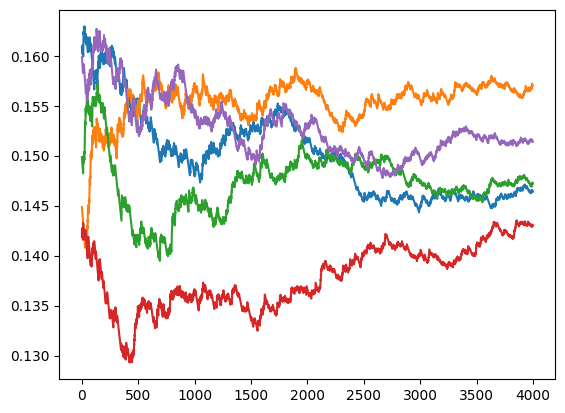

In [5]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,

    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=mu_prior_mean, scale=mu_prior_sigma, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma**2) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu, cov=(sigma0**2) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    print(logsumexp(marginal_likelihoods, axis=-1))
    print(np.log(num_samples))
    print(prior_likelihoods- log_marginal_likelihoods)
    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]

import matplotlib.pyplot as plt
# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean = mu_prior_mean,
        mu_prior_sigma = mu_prior_sigma,

        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
[ -5.84322437  -1.1098034  -11.26990744 ...  -6.17508479  -4.31014838
  -4.57919076]
8.517193191416238
[6.65999341 3.20627981 0.55678999 ... 7.0061588  5.86556508 6.03292361]
[ -9.33289973 -12.51807494  -3.10440274 ...  -8.42668955 -19.18471444
 -16.90083038]
8.517193191416238
[5.16272402 6.65726401 0.36730346 ... 5.0394336  4.28027822 6.22121847]
[ -4.20390987  -4.52464279 -14.26550862 ... -27.90399595 -17.30403819
 -12.89171362]
8.517193191416238
[-3.31059557 -3.04757652  4.45493014 ...  3.44648392  6.07035845
  3.82102088]
[-28.36565075 -12.66931502 -27.06400215 ... -14.51345699 -41.60862124
 -17.09581384]
8.517193191416238
[ 7.0196396  -0.72508913  7.26625635 ...  0.6618854  -7.39382765
  2.50262112]
[-27.78904121 -30.88899348 -31.46433563 ... -52.17168973 -46.92359973
  -6.26833671]
8.517193191416238
[  5.11755633   6.37407217   6.68358224 ... -11.40469965   0.63656006
 -10.981674  ]
[-46.10678552 -26.50427778 -52.79428159 ... -65.64491689 -

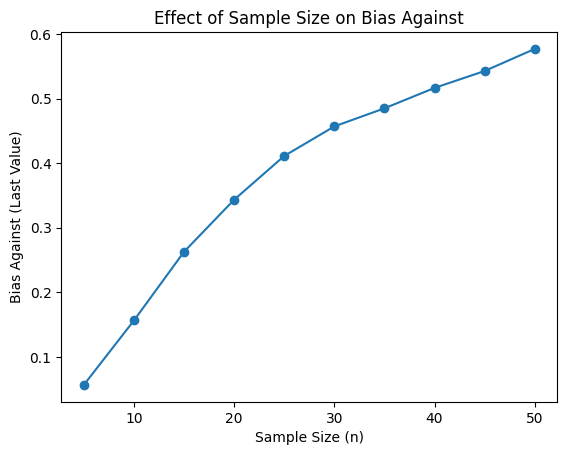

In [6]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 5))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


# BIAS IN FAVOR

[1.05 2.  ]


<ipython-input-4-f5b315314f6e>:79: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]


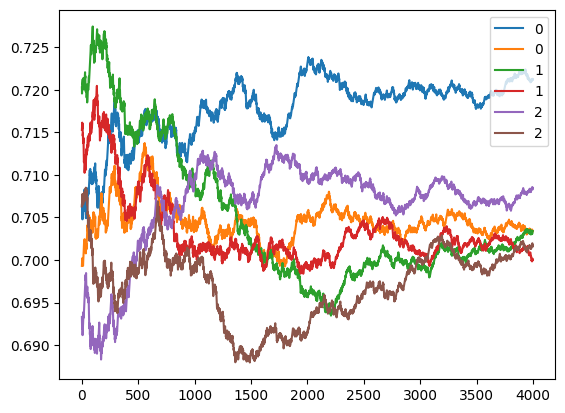

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            print(new_beta)
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov=(sigma ** 2) * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0 ** 2) * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

            # Compute log marginal likelihoods
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 3
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor[0], label = i)
    plt.plot(bias_in_favor[1], label=i)
plt.legend()
plt.show()

Looking at max only

0


<ipython-input-6-c1abfd844d4c>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


1
2
3
4
5


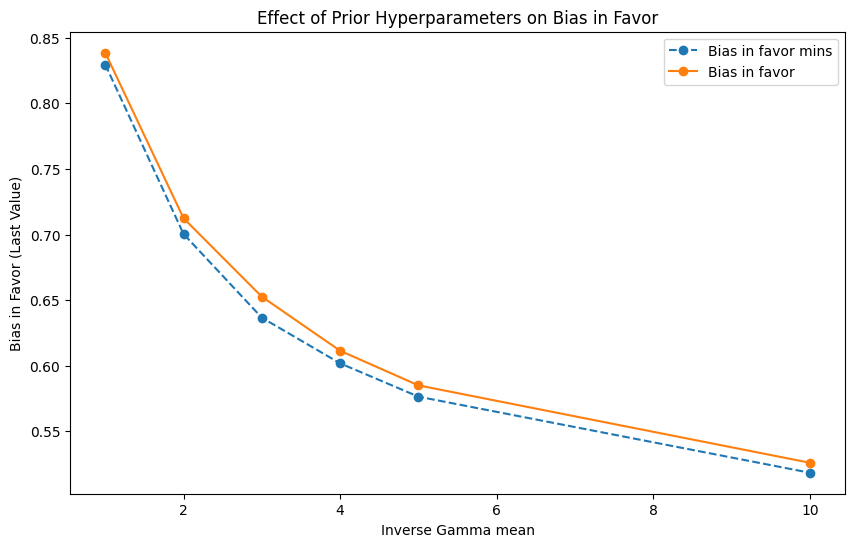

In [6]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot([1, 2, 3, 4, 5, 10] , mins, linestyle = "--", label = "Bias in favor mins", marker='o')
plt.plot([1, 2, 3, 4, 5, 10] , maxs, label = "Bias in favor", marker='o')
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


0


<ipython-input-3-167d5580829d>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


1
2
3
4
5


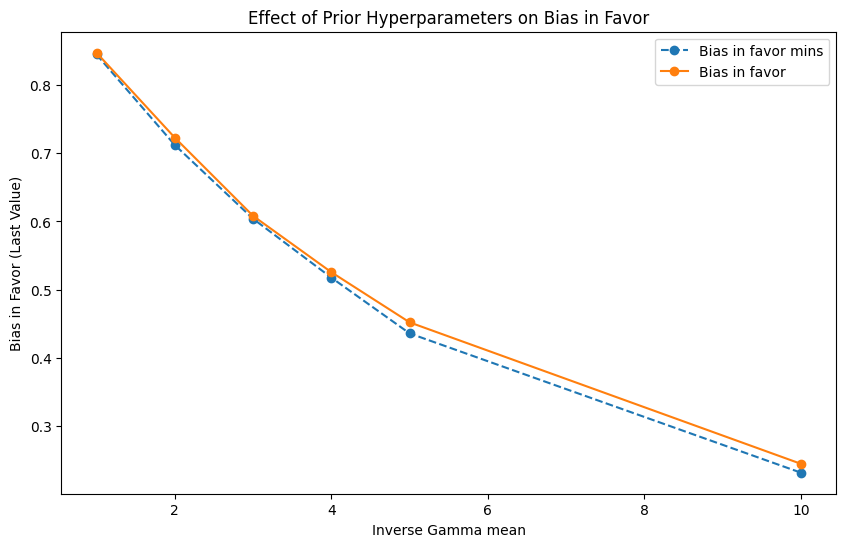

In [3]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot(beta_values, mins, linestyle = "--", label = "Bias in favor mins", marker = "o")
plt.plot(beta_values, maxs, label = "Bias in favor", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


[1.05 2.  ]


<ipython-input-5-102fb625a169>:79: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.05 2.  ]
[0.95 2.  ]
[1.   2.05]
[1.   1.95]


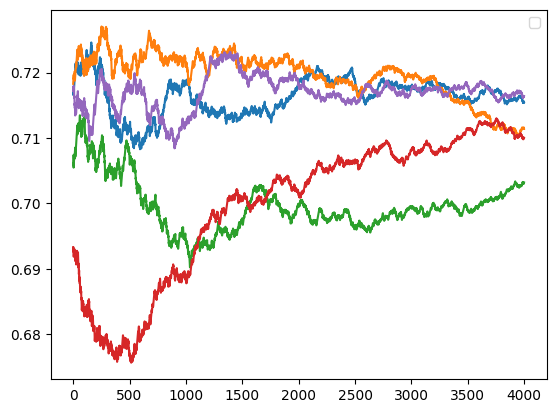

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            print(new_beta)
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov=(sigma ** 2) * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0 ** 2) * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

            # Compute log marginal likelihoods
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]

# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 3
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor)
plt.show()

# Changing delta

[1.01 2.  ]
[0.99 2.  ]
[1.   2.01]
[1.   1.99]
[1.05 2.  ]


<ipython-input-17-9abef40cb164>:79: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


[0.95 2.  ]
[1.   2.05]
[1.   1.95]
[1.1 2. ]
[0.9 2. ]
[1.  2.1]
[1.  1.9]
[1.25 2.  ]
[0.75 2.  ]
[1.   2.25]
[1.   1.75]
[1.5 2. ]
[0.5 2. ]
[1.  2.5]
[1.  1.5]
[2. 2.]
[0. 2.]
[1. 3.]
[1. 1.]
[3. 2.]
[-1.  2.]
[1. 4.]
[1. 0.]


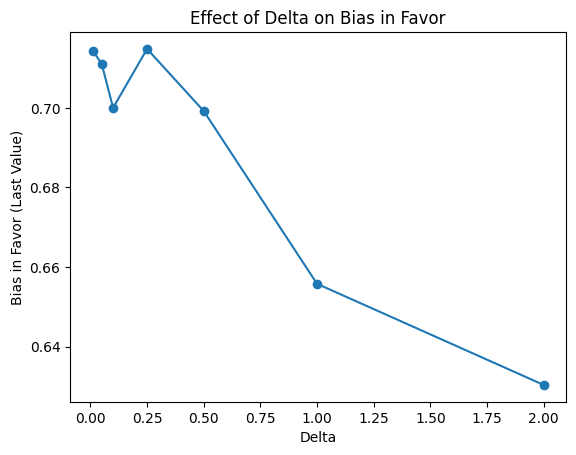

In [ ]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.01, 0.05, 0.10, 0.25, 0.50, 1, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(delta_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor")
plt.show()


In [ ]:
n_values = [int(i) for i in np.linspace(1, 50, num=50)[::5]]

print(n_values)

[1, 6, 11, 16, 21, 26, 31, 36, 41, 46]


[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


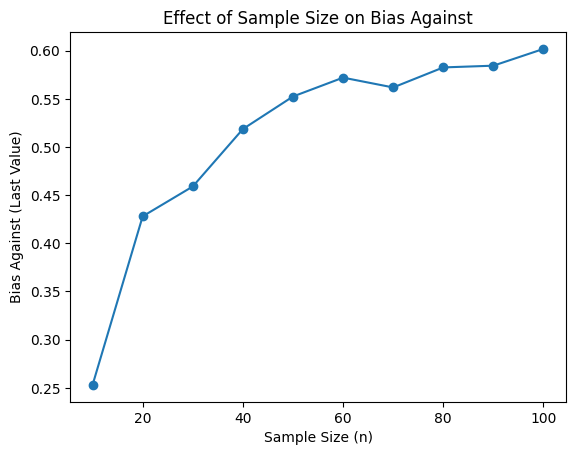

In [15]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


other

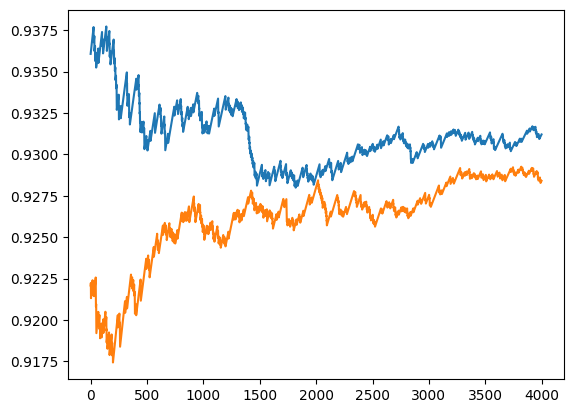

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov=(sigma ** 2) * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0 ** 2) * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]

# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor)
plt.show()


[5, 15, 25, 35, 45]


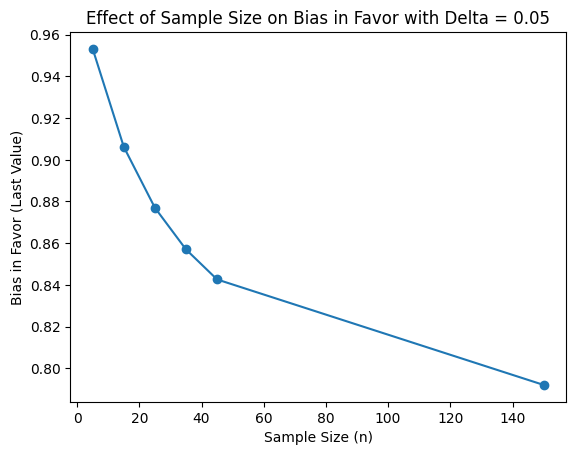

In [ ]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
n_values.append(150)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(n_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()


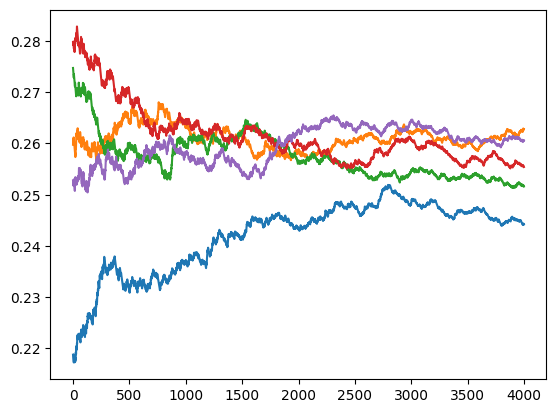

In [16]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,

    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=mu_prior_mean, scale=mu_prior_sigma, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]

import matplotlib.pyplot as plt
# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1

sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean = mu_prior_mean,
        mu_prior_sigma = mu_prior_sigma,

        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

In [12]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,

    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=mu_prior_mean, scale=mu_prior_sigma, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]


# Linear Regression

## Bias Against

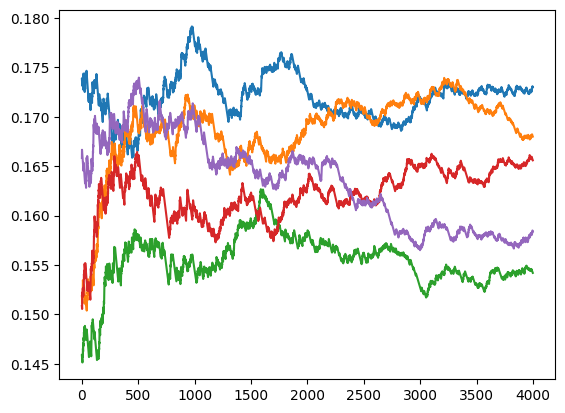

In [21]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,

    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]

import matplotlib.pyplot as plt
# Parameters
# Define prior parameters

sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,

        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

[5, 15, 25, 35, 45]


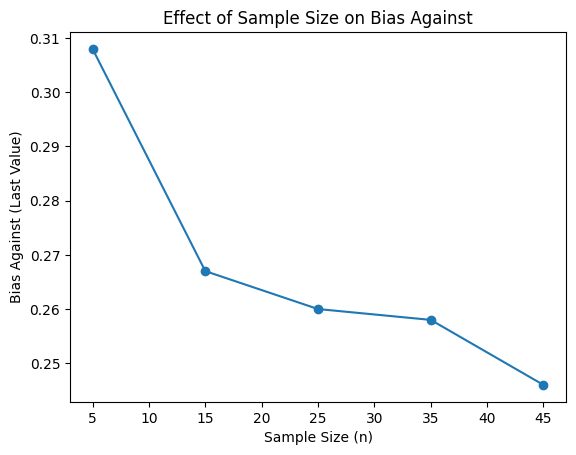

In [16]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


0
1
2
3
4
5


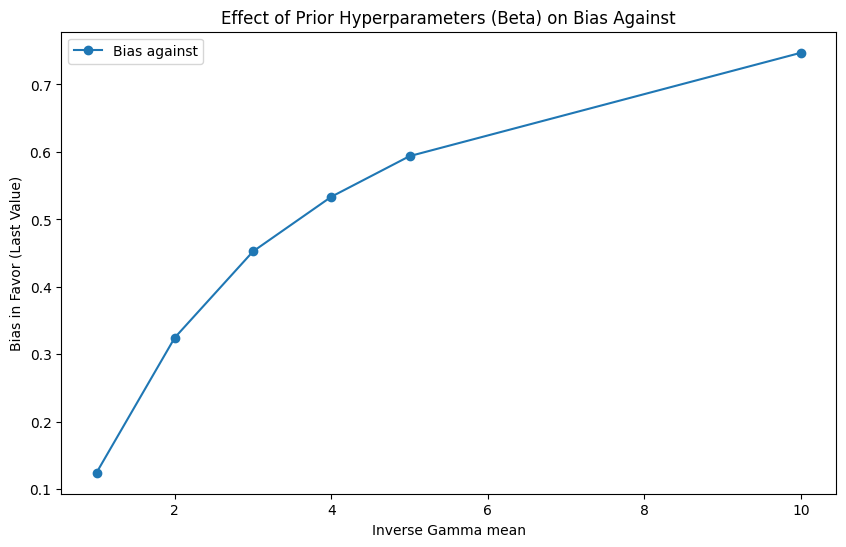

In [32]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]


# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)
        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot(beta_values, biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias Against')
plt.show()


0
1
2
3
4
5


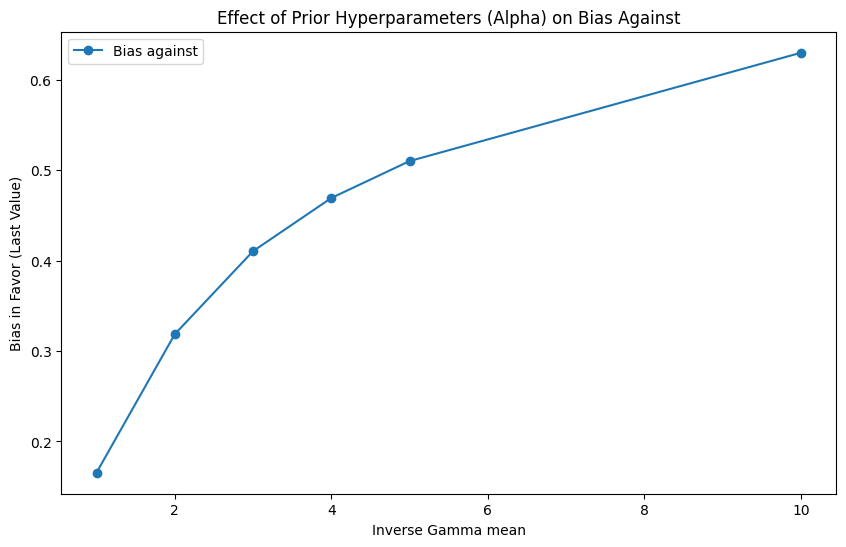

In [34]:

# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2, 2]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)

        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot([1,2,3,4,5,10], biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Alpha) on Bias Against')
plt.show()


# Bias in favor

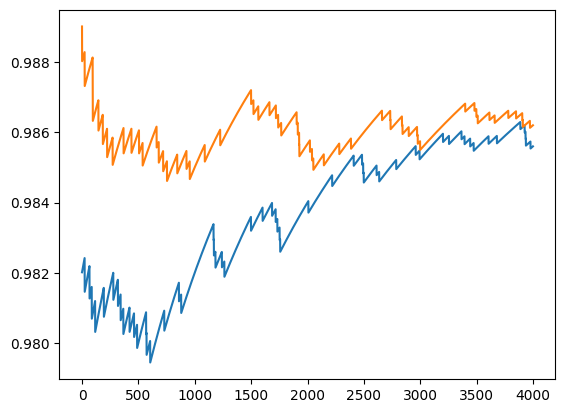

In [4]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]

# Parameters
# Define prior parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor)
plt.show()


In [24]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]


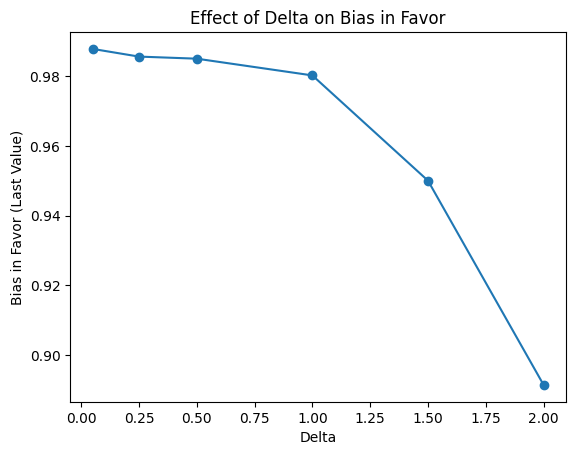

In [26]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.05, 0.25, 0.50, 1, 1.5, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(delta_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor")
plt.show()


[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
10
20
30
40
50
60
70
80
90
100


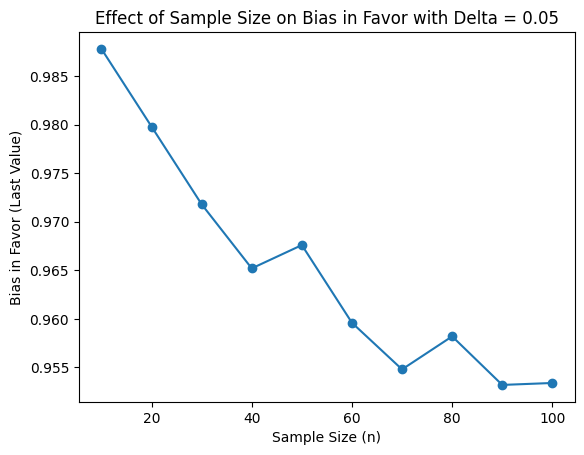

In [9]:

# Parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
for n in n_values:
    print(n)
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(n_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()


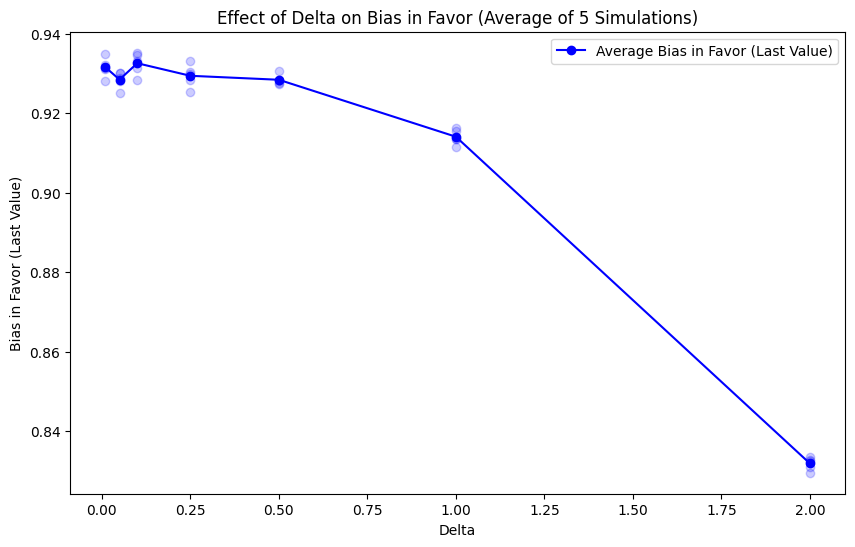

In [ ]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.01, 0.05, 0.10, 0.25, 0.50, 1, 2]
bias_in_favor_last_avg_values = []
all_bias_in_favor_last_values = []  # To store individual simulations for transparency

for delta in delta_values:
    # Run 5 simulations and collect results
    simulations = []
    for _ in range(5):
        bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
            n_sample=n,
            beta0=beta0,
            X=X,
            sigma0=sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=sigma_prior_alpha,
            sigma_prior_beta=sigma_prior_beta,
            delta=delta,
            cumulative=False,
            n_datasets=1000
        )
        simulations.append(bias_in_favor_last)

    # Average of the 5 simulations for current delta
    avg_bias_in_favor_last = np.mean(simulations)
    bias_in_favor_last_avg_values.append(avg_bias_in_favor_last)
    all_bias_in_favor_last_values.append(simulations)  # Store for plotting transparency

# Plotting
plt.figure(figsize=(10, 6))

# Plot individual simulations with transparency
for i, delta in enumerate(delta_values):
    plt.scatter([delta] * 5, all_bias_in_favor_last_values[i], color='blue', alpha=0.2)

# Plot the average of the 5 simulations for each delta
plt.plot(delta_values, bias_in_favor_last_avg_values, marker='o', color='blue', label='Average Bias in Favor (Last Value)')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor (Average of 5 Simulations)")
plt.legend()
plt.show()


### Changing the alpha hyperparameter

0
1


<ipython-input-28-e6fd1405c605>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


2
3
4
5


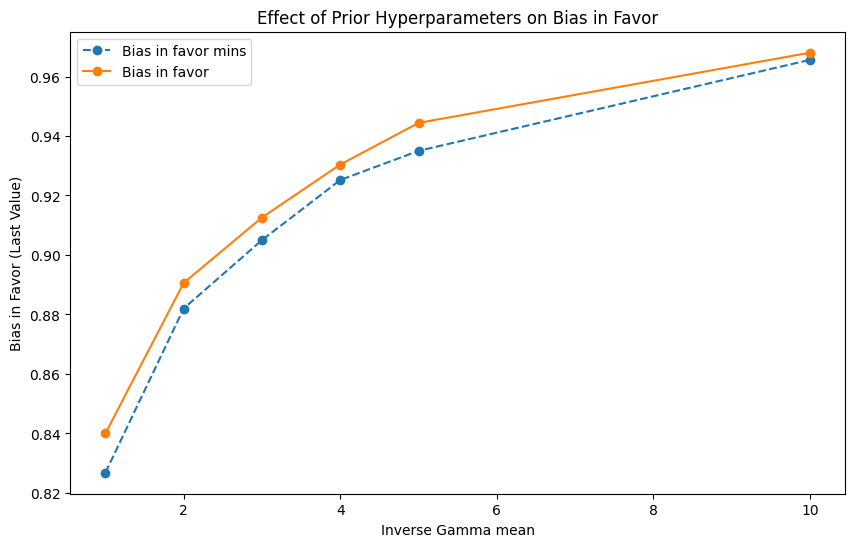

In [28]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot([1, 2, 3, 4, 5, 10] , mins, linestyle = "--", label = "Bias in favor mins", marker='o')
plt.plot([1, 2, 3, 4, 5, 10] , maxs, label = "Bias in favor", marker='o')
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


### Changing the beta hyperparameter

0


<ipython-input-30-8de1be8376f0>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


1
2
3
4
5


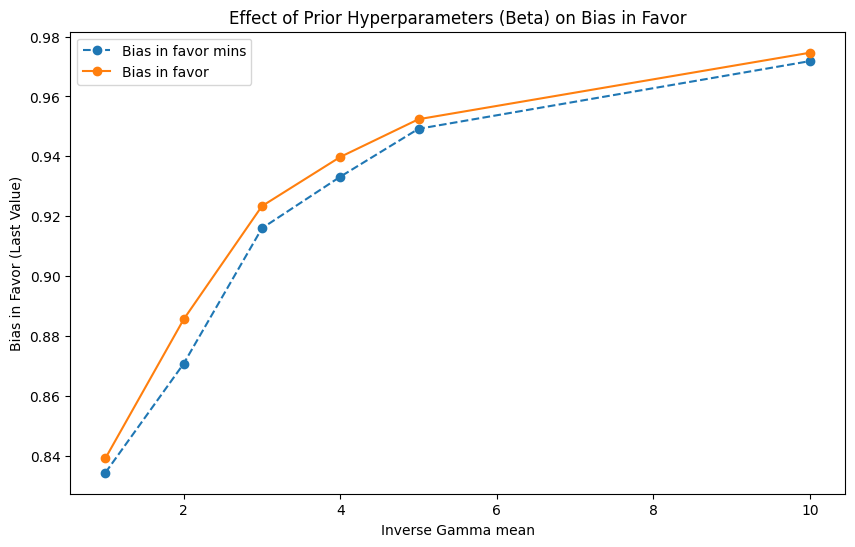

In [30]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot(beta_values, mins, linestyle = "--", label = "Bias in favor mins", marker = "o")
plt.plot(beta_values, maxs, label = "Bias in favor", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias in Favor')
plt.show()
